In [2]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# ── 图像读取与基础属性 ────────────────────────────────
img_bgr = cv2.imread('sample.jpg')              # BGR 格式（OpenCV 默认）
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # 转 RGB 用于 matplotlib
print(f"图像尺寸: {img_rgb.shape}")             # (H, W, C)
print(f"像素值范围: [{img_rgb.min()}, {img_rgb.max()}]")

图像尺寸: (1047, 1100, 3)
像素值范围: [0, 255]


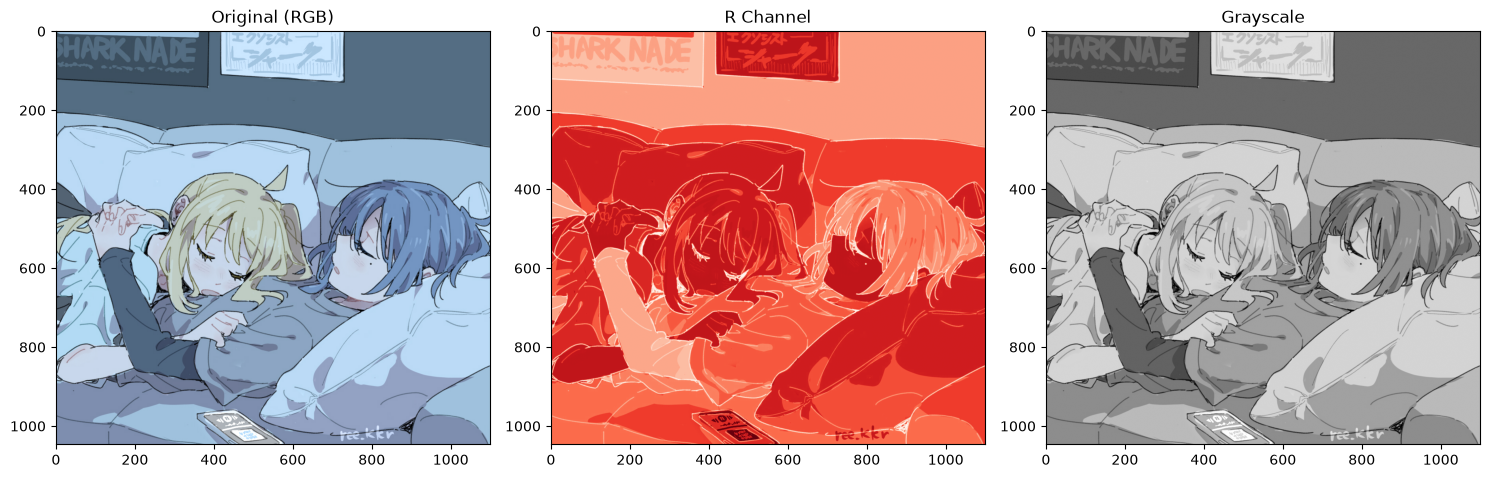

In [4]:
# ── 显示图像（Notebook 中）────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original (RGB)')
axes[1].imshow(img_rgb[:,:,0], cmap='Reds')
axes[1].set_title('R Channel')
axes[2].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), cmap='gray')
axes[2].set_title('Grayscale')
plt.tight_layout(); plt.show()

In [5]:
# ── 常用图像变换 ──────────────────────────────────────
# 缩放
resized = cv2.resize(img_bgr, (224, 224))
resized_keep = cv2.resize(
    img_bgr,
    (int(img_bgr.shape[1] * 0.5), int(img_bgr.shape[0] * 0.5))
)

# 归一化（0-255 → 0-1，训练必须做）
img_float = img_rgb.astype(np.float32) / 255.0
# ImageNet 标准化
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img_normalized = (img_float - mean) / std

# 颜色空间转换
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

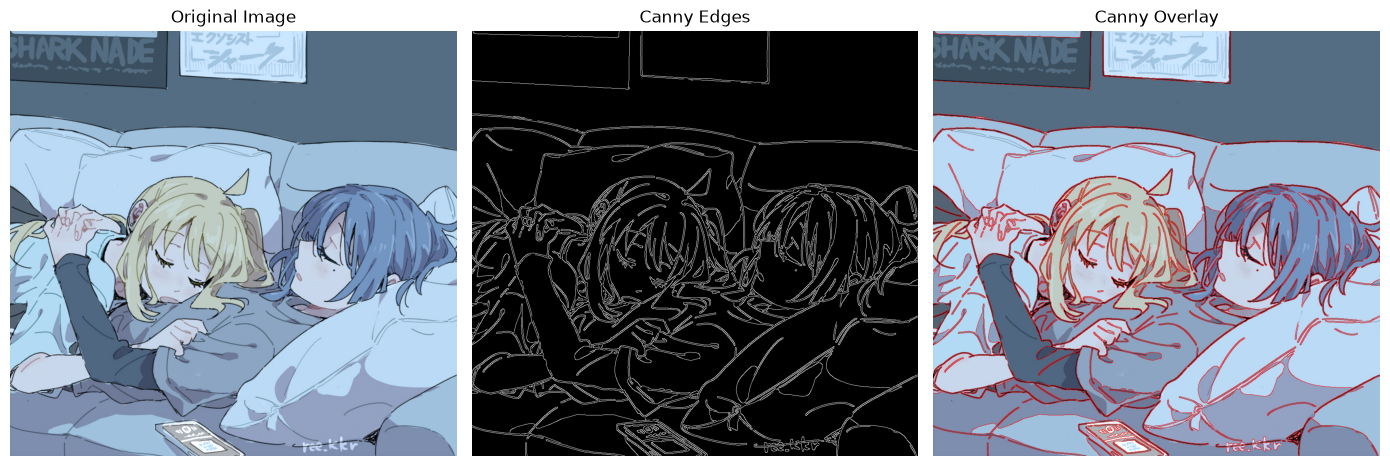

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── 边缘检测（理解图像特征）────────────────────────────
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges_canny = cv2.Canny(blurred, threshold1=50, threshold2=150)

# Sobel 梯度
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
gradient_mag = np.sqrt(sobelx**2 + sobely**2)

# ── 在 Jupyter Lab 中显示图像 ─────────────────────────────

# OpenCV 读取的是 BGR，matplotlib 显示需要 RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 将 Canny 边缘叠加到原图上
overlay = img_rgb.copy()
overlay[edges_canny > 0] = [255, 0, 0]  # 红色边缘

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Canny Edges")
plt.imshow(edges_canny, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Canny Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

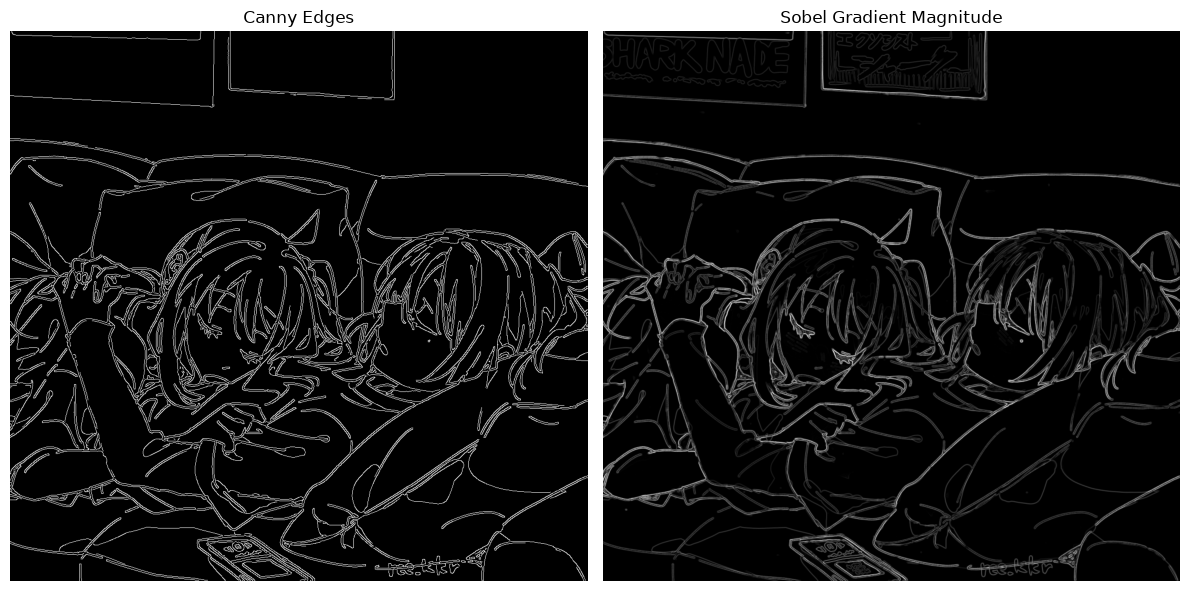

In [7]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Canny Edges")
plt.imshow(edges_canny, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Sobel Gradient Magnitude")
plt.imshow(gradient_mag, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

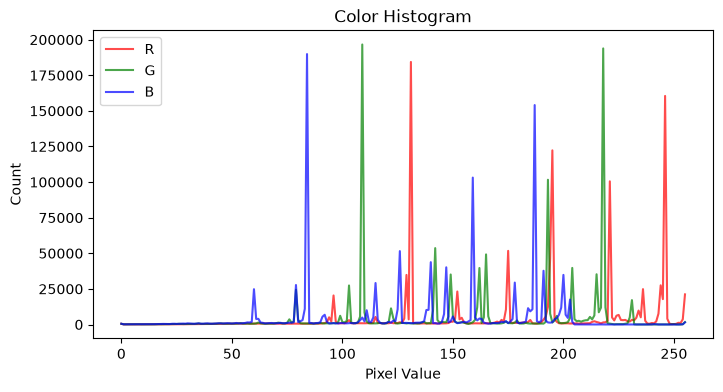

In [9]:
# ── 像素直方图 ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors = ('r', 'g', 'b')
for i, color in enumerate(colors):
    hist = cv2.calcHist([img_bgr], [i], None, [256], [0, 256])
    ax.plot(hist.flatten(), color=color, alpha=0.7, label=color.upper())
ax.set_xlabel('Pixel Value'), ax.set_ylabel('Count')
ax.set_title('Color Histogram')
ax.legend(); plt.savefig('histogram.pdf', bbox_inches='tight'); plt.show()